<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Factors/Route_Alice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impact of Route to Everest Summit

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly
import plotly.express as px
import warnings
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col
import re
warnings.filterwarnings('ignore')
sns.set(font_scale=1.5)
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 8)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.5 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3


In [18]:
from google.colab import files
uploaded = files.upload()


filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)




Saving expeditions5.csv to expeditions5.csv


In [19]:
df_recent = df[df['Year'] >= 1990]

Cleaning the data in the route column.

Encoding the top 5 most common routes with numbers 1-5 to make it easier to use.

In [ ]:
df_recent['clean_routes'] = (
    df_recent['Route(s)']
    .dropna()
    .str.lower()
    .str.replace(r'\(.*?\)', '', regex=True)   # remove notes in parentheses
    .str.replace(',', '/', regex=False)
    .str.replace(';', '/', regex=False)        # normalize separators
    .str.split('/')                            # split routes
    .str[0]                                    # keep FIRST route only
    .str.replace(r'\s+', ' ', regex=True)      # normalize spaces
    .str.strip()                               # remove whitespace
)

df_recent['route_codes'] = (
    df_recent['clean_routes']
    .map({
        's col-se ridge': 1,
        'n col-ne ridge': 2,
        'n face': 3,
        'sw face': 4,
        's pillar-se ridge': 5,
        'n col': 2,
    })
    .fillna(6)
)

Same process of cleaning and encoding the results data to produce a column for success rate.

In [ ]:
df_recent['result_clean'] = (
    df_recent['Result']
    .astype(str)
    .str.lower()
    .str.replace(r'\(.*?\)', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df_recent['result_code'] = (
    df_recent['result_clean']
    .map({
        'success': 1,
        'accident': 2,
        'route difficulty': 3,
        'illness, ams': 4,
        'lack of supplies': 5,
        'bad weather': 6,
        'bad conditions': 6,
        'other': 7,
        'lack of time': 8,
        'did not climb': 9,
        'unknown': 10
    })
    .fillna(11)
    .astype(int)
)
df_recent['grp_success']= np.where(df_recent['Result_clean'] == 'success', 1, 0)

We have two ways to measure success rate - success of the expedition (an expedition is a success even if just 1 of 30 people summitted, for example), OR success rate of the expedition (i.e. each expedition has a value summitters/group size).

In this file i call the former grp_success (grouped_success) and the latter success_rate (yearly_success)

In [5]:
df_recent['success_rate'] = pd.to_numeric(df_recent['success_rate'], errors='coerce').fillna(0)

In [6]:
grouped_success = df_recent.groupby('Year')['grp_success'].mean().reset_index()
yearly_success = df_recent.groupby('Year')['success_rate'].mean().reset_index()

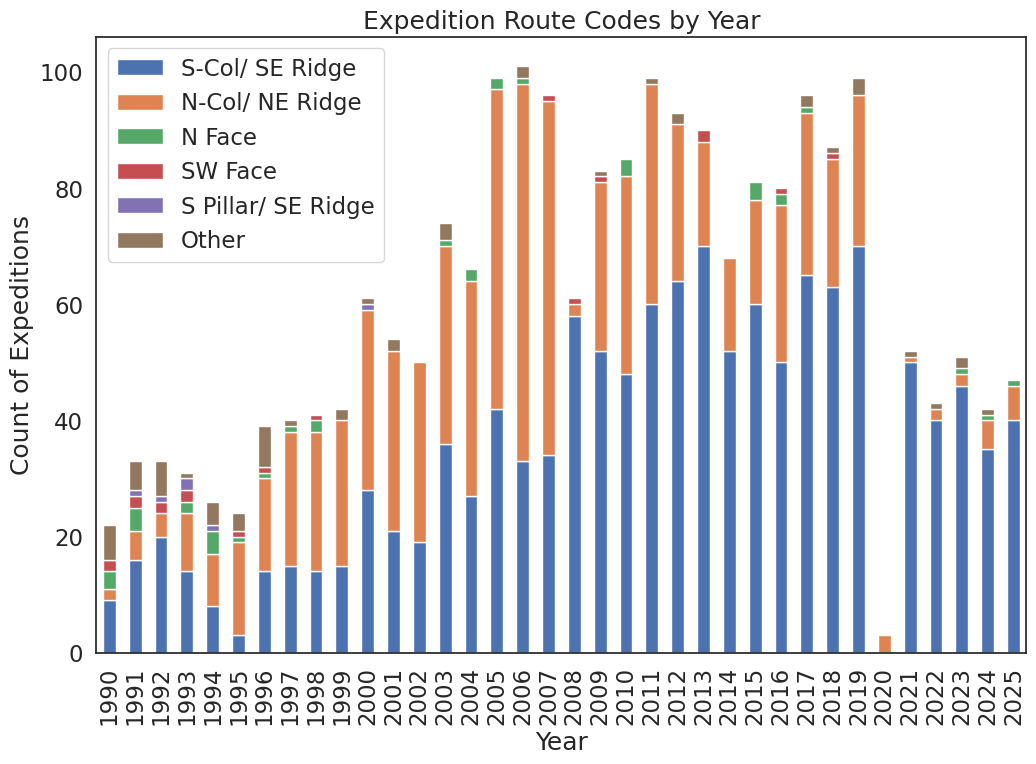

In [7]:
routedf = pd.crosstab(df_recent['Year'], df_recent['route_codes'])

ax1 = routedf.plot(kind='bar', stacked=True)
ax1.set_xlabel('Year')
ax1.set_ylabel('Count of Expeditions')
ax1.set_title('Expedition Route Codes by Year')
ax1.legend(['S-Col/ SE Ridge', 'N-Col/ NE Ridge', 'N Face', 'SW Face', 'S Pillar/ SE Ridge', 'Other'])
plt.show()

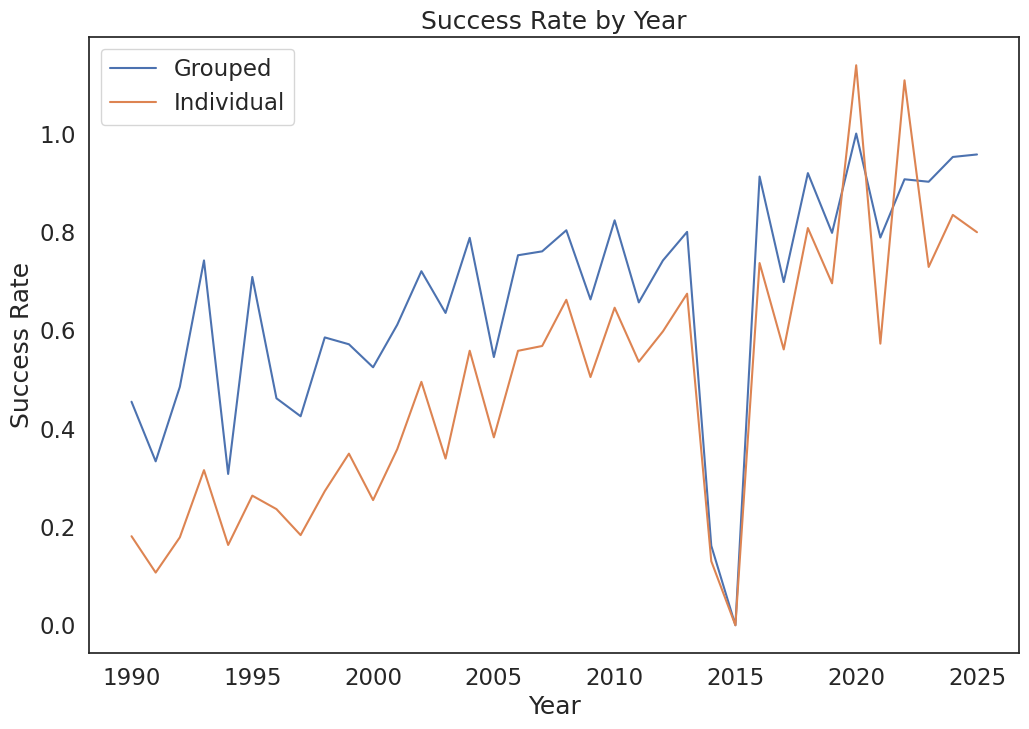

In [8]:
fig, ax2 = plt.subplots()
ax2.plot(grouped_success['Year'], grouped_success['grp_success'])
ax2.plot(yearly_success['Year'], yearly_success['success_rate'])
ax2.set_xlabel('Year')
ax2.set_ylabel('Success Rate')
ax2.set_title('Success Rate by Year')
ax2.legend(['Grouped', 'Individual'])
plt.show()

In [9]:
routes_by_year = df_recent.groupby(['Year', 'route_codes']).size().reset_index(name='count')
route_labels = {
    1: 'S-Col/ SE Ridge',
    2: 'N-Col/ NE Ridge',
    3: 'N Face',
    4: 'SW Face',
    5: 'S Pillar/ SE Ridge',
    6: 'Other'
}
routes_by_year['route_label'] = routes_by_year['route_codes'].map(route_labels).fillna(routes_by_year['route_codes'])

fig = px.bar(
    routes_by_year,
    x='route_label',
    y='count',
    animation_frame='Year',
    category_orders={
        'route_label': list(route_labels.values())
    },
    title='Number of Expeditions per Route by Year',
    labels={
        'count': 'Number of Expeditions',
        'route_label': ''
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_range=[0, routes_by_year['count'].max() + 5],
    transition={'duration': 300},
    updatemenus=[dict(type='buttons',
                  showactive=False,
                  y=-0.50,
                  x=-0.05,
                  xanchor='left',
                  yanchor='bottom')
                        ]
)
fig.update_traces(marker_color='steelblue')
fig['layout']['sliders'][0]['pad']=dict(r= 70, t= 80,)
fig.show()


Making an interactive animated graph in plotly: https://plotly.com/python/animations/
AND https://plotly.com/python/bar-charts/#bar-chart-with-plotly-express

Changing the location of the slider/buttons: https://community.plotly.com/t/how-can-i-move-the-animation-play-button-and-slider-closer-to-the-plot/48646


In [10]:
routes_by_year

,Year,route_codes,count,route_label
0,1990,1,9,S-Col/ SE Ridge
1,1990,2,2,N-Col/ NE Ridge
2,1990,3,3,N Face
3,1990,4,2,SW Face
4,1990,6,6,Other
...,...,...,...,...
126,2024,3,1,N Face
127,2024,6,1,Other
128,2025,1,40,S-Col/ SE Ridge
129,2025,2,6,N-Col/ NE Ridge


In [11]:
total_route_success = df_recent.groupby('route_codes')['grp_success'].mean().reset_index()
yearly_route_success = df_recent.groupby(['Year', 'route_codes'])['grp_success'].mean().reset_index()


In [14]:
total_route_success_rate = df_recent.groupby('route_codes')['success_rate'].mean().reset_index()
yearly_route_success_rate = df_recent.groupby(['Year', 'route_codes'])['success_rate'].mean().reset_index()
total_route_success_rate

,route_codes,success_rate
0,1,0.556039
1,2,0.475764
2,3,0.090594
3,4,0.152469
4,5,0.247896
5,6,0.111307


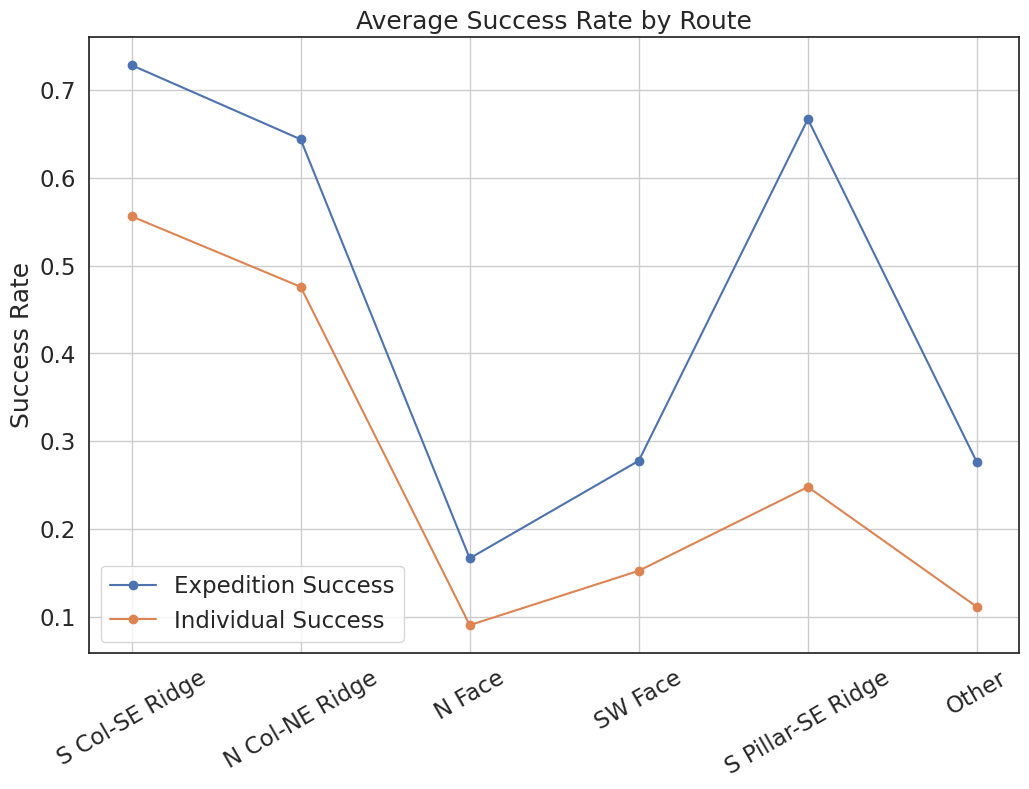

In [13]:
plt.plot(total_route_success['route_codes'], total_route_success['grp_success'], label='Expedition Success', marker='o')
plt.plot(total_route_success_rate['route_codes'], total_route_success_rate['success_rate'], label='Individual Success', marker='o')
plt.xlabel('')
plt.xticks(ticks=[1,2,3,4,5,6], labels=['S Col-SE Ridge', 'N Col-NE Ridge', 'N Face', 'SW Face', 'S Pillar-SE Ridge', 'Other'], rotation=30)
plt.ylabel('Success Rate')
plt.title('Average Success Rate by Route')
plt.legend()
plt.grid()
plt.show()

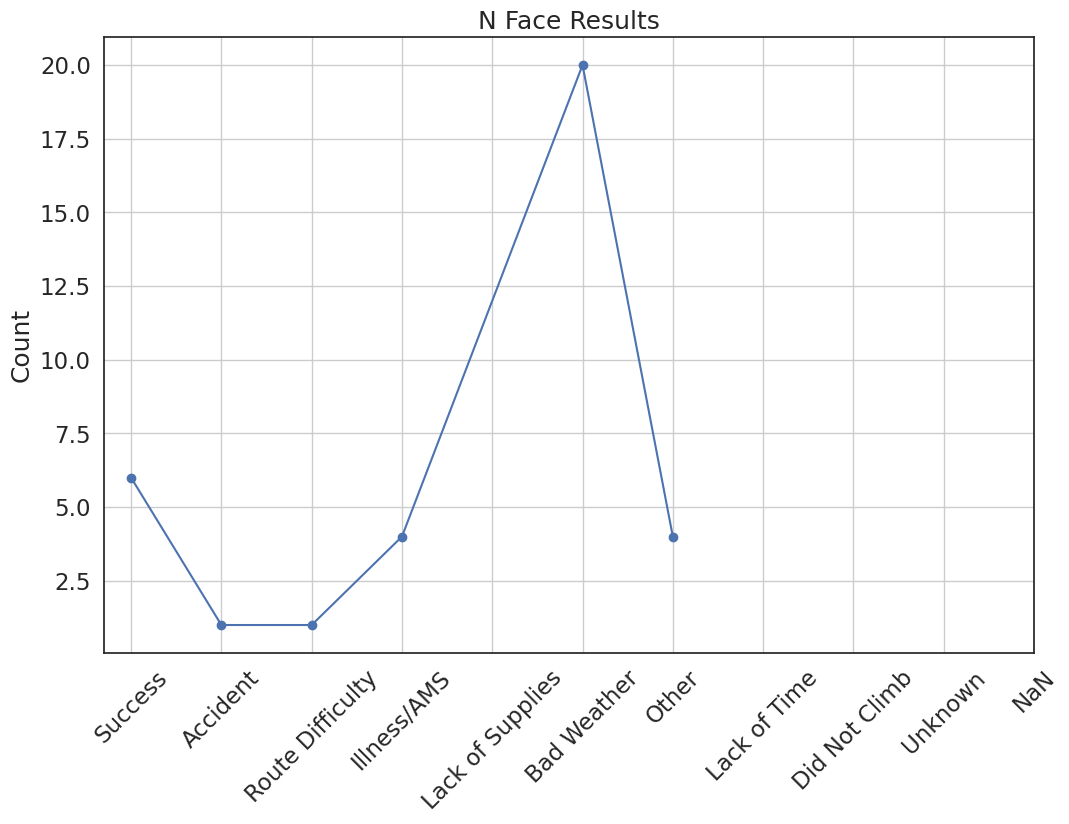

In [ ]:
#What goes wrong on N Face?
Nface_df = df_recent[df_recent['route_codes'] == 3]
Nface_results = Nface_df['result_code'].value_counts().sort_index()
plt.plot(Nface_results.index, Nface_results.values, marker='o')
plt.xlabel('')
plt.xticks(ticks=[1,2,3,4,5,6,7,8,9,10,11],labels = ['Success', 'Accident', 'Route Difficulty', 'Illness/AMS', 'Lack of Supplies', 'Bad Weather', 'Other', 'Lack of Time', 'Did Not Climb', 'Unknown', 'NaN'],rotation=45)
plt.ylabel('Count')
plt.title('N Face Results')
plt.grid()
plt.show()

So the North face has terrible weather!

In [15]:
total_route_death = df_recent.groupby('route_codes')['total_DR'].mean().reset_index()
yearly_route_death = df_recent.groupby(['Year', 'route_codes'])['total_DR'].mean().reset_index()
total_route_death

,route_codes,total_DR
0,1,0.013622
1,2,0.018349
2,3,0.006740
3,4,0.108333
4,5,0.015152
5,6,0.005743


In [20]:
sum_route_death = df_recent.groupby('route_codes')['total_death'].sum().reset_index()
sum_route_death

,route_codes,total_death
0,1,149
1,2,69
2,3,3
3,4,6
4,5,1
5,6,6


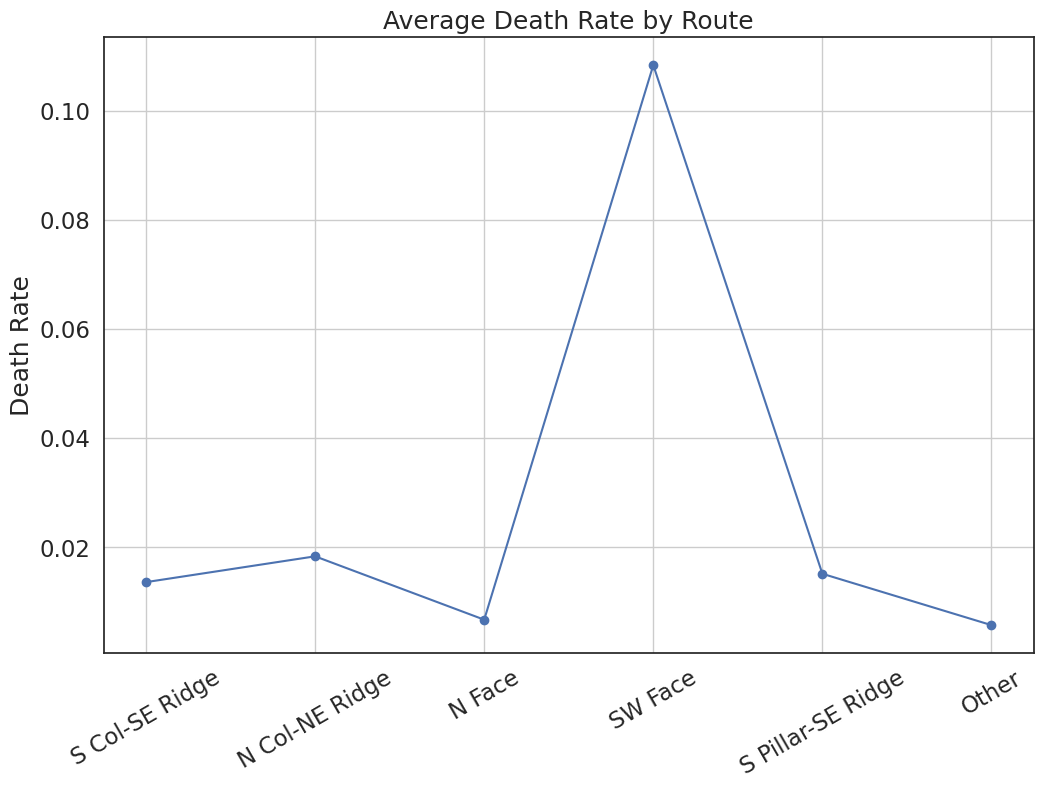

In [16]:
plt.plot(total_route_death['route_codes'], total_route_death['total_DR'], marker='o')
plt.xlabel('')
plt.xticks(ticks=[1,2,3,4,5,6], labels=['S Col-SE Ridge', 'N Col-NE Ridge', 'N Face', 'SW Face', 'S Pillar-SE Ridge', 'Other'], rotation=30)
plt.ylabel('Death Rate')
plt.title('Average Death Rate by Route')
plt.grid()
plt.show()

So the South West Face has the highest death rate of all the routes!

(It's all pretty low though)

In [ ]:
#What about route success by year?
yearly_route_success['route_label'] = yearly_route_success['route_codes'].map(route_labels).fillna(yearly_route_success['route_codes'])

fig2 = px.bar(
    yearly_route_success,
    x='route_label',
    y='grp_success',
    animation_frame='Year',
    category_orders={
        'route_label': list(route_labels.values())
    },
    title='Expedition Success Rate of Each Route by Year',
    labels={
        'grp_success': 'Success Rate',
        'route_label': ''
    }
)
fig2.update_layout(
    xaxis_tickangle=-45,
    yaxis_range=[0, yearly_route_success['grp_success'].max()],
    updatemenus=[dict(type='buttons',
                  showactive=False,
                  y=-0.50,
                  x=-0.05,
                  xanchor='left',
                  yanchor='bottom')
                        ]
)
fig2['layout']['sliders'][0]['pad']=dict(r= 70, t= 80,)
fig2.show()

This is great, but it is misleading when routes that are rarely used show high success rates.
I want a visualisation that include the fact that only S-Col and N-Col are popular.
Hence, a histogram:

In [ ]:
df_recent['route_label'] = df_recent['route_codes'].map(route_labels).fillna(df_recent['route_codes'])

fig3 = px.histogram(
    df_recent,
    x='route_label',
    y='grp_success',
    animation_frame='Year',
    category_orders={
        'route_label': list(route_labels.values())
    },
    labels={
        'grp_success': 'Success Rate',
        'route_label': 'Routes'
    }
)
fig3.update_layout(
    yaxis_range=[0, 65],
)
fig3.show()

A good comparison year here is 1994. The histogram shows us that this was a pretty unsuccessful year, whereas the bar graph just shows us that S-Pillar was 100% successful.

Let's create an alternative for Individual Success, just so we have covered all bases!

In [ ]:
fig4 = px.histogram(
    df_recent,
    x='route_label',
    y='success_rate',
    animation_frame='Year',
    category_orders={
        'route_label': list(route_labels.values())
    },
    labels={
        'success_rate': 'Success Rate',
        'route_label': 'Routes'
    }
)
fig4.update_layout(
    yaxis_range=[0, 51],
)
fig4.show()